# Quantum Circuit Born Machine with 2 Qubits

This code builds a QCBM using two qubits. The goal is to learn a simple distribution with that has only four outcomes (thus two qubits can suffice)

In [ ]:
import numpy as np
import pennylane as qml
import torch
from torch import nn
import matplotlib.pyplot as plt

In [1]:
import warnings
warnings.filterwarnings("ignore", category= UserWarning)

**Setting device for PyTorch**

This step depends on the system. For Apple Silicon, "mps" is the framework that enables hardware acceleration. For other hardware, the framework is "CUDA". 

When in doubt, setting device to "cpu" will always work. In that case, hardware acceleration is disabled. 

In [3]:
torch.manual_seed(42)
device = "mps"

In [4]:
def computational_basis():
    return torch.tensor([
        [0.0, 0.0],
        [0.0, 1.0],
        [1.0, 0.0],
        [1.0, 1.0],
    ], dtype=torch.float32)

# MMD and Kernel matrix

For a QCBM, the Maximum Mean Discrepancy is the most logical loss. Such a loss can be written as $\mathcal{L} = ...$ 


In [5]:
target_probs = torch.tensor([0.1, 0.3, 0.4, 0.2], dtype=torch.float32)

def rbf_kernel_matrix(X, sigmas):
    X_i = X[:, None, :]
    X_j = X[None, :, :]

    pairwise_dist2 = ((X_i - X_j) ** 2).sum(dim=-1)  

    sigmas = sigmas.view(-1, 1, 1)                  # (c,1,1)
    K = torch.exp(-pairwise_dist2.unsqueeze(0) / (2 * sigmas**2)).mean(dim=0)
    return K

sigmas = torch.tensor([0.5, 1.0, 2.0], device=device)
X = computational_basis().to(device)
K = rbf_kernel_matrix(X, sigmas)

In [6]:
def MMD_from_probability_vectors(p: torch.Tensor, q: torch.Tensor, K: torch.Tensor) -> torch.Tensor:
    p = p.view(-1, 1).to(device)
    q = q.view(-1, 1).to(device)
    
    sample_expecation = torch.matmul(p.T,torch.matmul(K, p).to(device))
    cross_term_expecation = torch.matmul(p.T ,torch.matmul(K , q).to(device))
    target_expecation = torch.matmul(q.T, torch.matmul(K, q).to(device))

    return (sample_expecation + target_expecation - 2.0 * cross_term_expecation).squeeze()

# Network

In [7]:
class QCBM(nn.Module):
    def __init__(self, n_qubits, n_layers):
        super().__init__()
        self.n_qubits = n_qubits
        self.n_layers = n_layers

        self.dev = qml.device("default.qubit", wires = n_qubits, shots = None)

        random_init = torch.randn(n_layers, n_qubits, 3) / 100
        self.weights = nn.Parameter(random_init)
        
        @qml.qnode(self.dev, interface="torch", diff_method="parameter-shift")
        def circuit(weights):
            qml.StronglyEntanglingLayers(weights, wires=np.arange(n_qubits))
            return qml.probs(wires=np.arange(n_qubits))
        
        self.circuit = circuit
    
    def forward(self):
        return self.circuit(self.weights)

# Network Definition and Training

In [18]:
qcbm_2layers = QCBM(n_qubits=2, n_layers=2)

/var/folders/9z/3xyc2zw91vd24987h9g19ltc0000gn/T/ipykernel_55346/2724813968.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


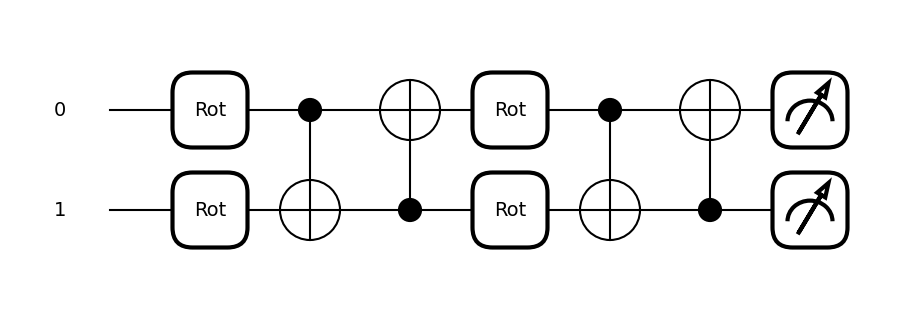

In [19]:
fig, ax = qml.draw_mpl(qcbm_2layers.circuit)(qcbm_2layers.weights)
fig.show()

In [15]:
network_info = qml.specs(qcbm_2layers.circuit)(qcbm_2layers.weights)
print(network_info)

{'resources': Resources(num_wires=2, num_gates=8, gate_types=defaultdict(<class 'int'>, {'Rot': 4, 'CNOT': 4}), gate_sizes=defaultdict(<class 'int'>, {1: 4, 2: 4}), depth=6, shots=Shots(total_shots=None, shot_vector=())), 'errors': {}, 'num_observables': 1, 'num_trainable_params': 12, 'num_device_wires': 2, 'num_tape_wires': 2, 'device_name': 'default.qubit', 'level': 'gradient', 'gradient_options': {}, 'interface': 'torch', 'diff_method': 'parameter-shift', 'gradient_fn': 'pennylane.gradients.parameter_shift.param_shift', 'num_gradient_executions': 24}


In [20]:
optimiser = torch.optim.Adam(qcbm_2layers.parameters(), lr=0.0008)

def train_iteration(network, dist_to_train, kernel, opt):
    opt.zero_grad

    p = torch.as_tensor(network(), dtype=torch.float32)
    loss = MMD_from_probability_vectors(p, dist_to_train, kernel)

    loss.backward()
    opt.step()

    return loss.item(), p.detach()

loss_history = []

for step in range(1, 1501):
    loss, p = train_iteration(qcbm_2layers, target_probs, K, optimiser)
    loss_history.append(loss)
    if step % 50 == 0:
        print(f"step {step:3d} | loss={loss:.6f} | p={p.numpy()}")


print("\nTarget:", target_probs.numpy())
print("Final :", qcbm_2layers().detach().numpy())

step  50 | loss=0.517906 | p=[9.9611998e-01 7.6187693e-04 5.7325326e-04 2.5448881e-03]
step 100 | loss=0.496274 | p=[0.97878534 0.00370331 0.002735   0.01477634]
step 150 | loss=0.454245 | p=[0.9439216  0.00935335 0.00615863 0.04056637]
step 200 | loss=0.395744 | p=[0.8919322  0.01767352 0.01027529 0.08011899]
step 250 | loss=0.327875 | p=[0.8246091  0.02923699 0.01498026 0.13117363]
step 300 | loss=0.258566 | p=[0.74434674 0.04519122 0.02111975 0.18934228]
step 350 | loss=0.195011 | p=[0.65443486 0.06633195 0.03022676 0.24900645]
step 400 | loss=0.142343 | p=[0.5595428  0.09212802 0.04430784 0.3040214 ]
step 450 | loss=0.102454 | p=[0.4655787  0.12024368 0.06560637 0.34857127]
step 500 | loss=0.073723 | p=[0.37885144 0.14675267 0.09655129 0.3778446 ]
step 550 | loss=0.052154 | p=[0.30474198 0.16689701 0.14016119 0.38819984]
step 600 | loss=0.033867 | p=[0.24611628 0.1762621  0.2008559  0.37676573]
step 650 | loss=0.018877 | p=[0.2018979  0.1733114  0.28166825 0.34312245]
step 700 | lo

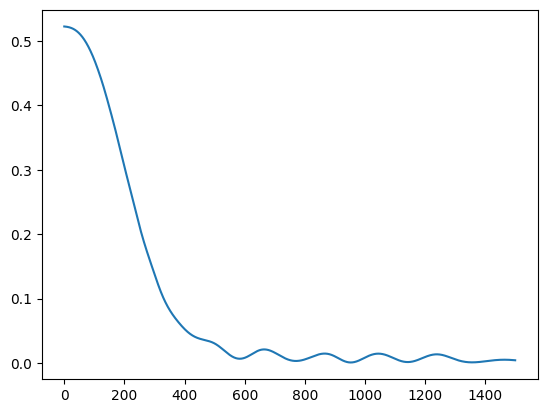

In [151]:
plt.plot(loss_history)